___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Q-Learning


Before diving into the topic of **Deep Reinforcement** it is important to get to know the basic concepts of Reinforcement Learning as this allows us to improve our understanding of the whole field.

To do so we take a look at one of the most known classical Reinforcement Learning algorithm called **Q-Learning** and apply this algorithm on the CartPole environment https://gym.openai.com/envs/CartPole-v1/

Let us first take a look at the game and start with the necessary imports

# Part 0 : Imports

In [1]:
%pip install pyglet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib notebook
import time  # slow the game down a little bit
from pyglet.window import key  # for manual playing

import gymnasium as gym
import numpy as np  # used for all kinds of matrix / vector operations
import matplotlib.pyplot as plt  # for plotting

In [3]:
import warnings
warnings.filterwarnings(action="ignore")

In [4]:
%config InlineBackend.figure_format = "retina"

# Part 1: Environment Setup

In [5]:
env = gym.make("CartPole-v1" , render_mode = "human")  # We want to solve the CartPole task
state , info = env.reset()  # Reset to initial state
for _ in range(100):
    env.render()  # Render on the screen
    action = env.action_space.sample()  # chose a random action
    env.step(action)  # Perform random action on the environment
    time.sleep(0.1)
env.close()  # dont forget to close the environment

In [6]:
%matplotlib inline

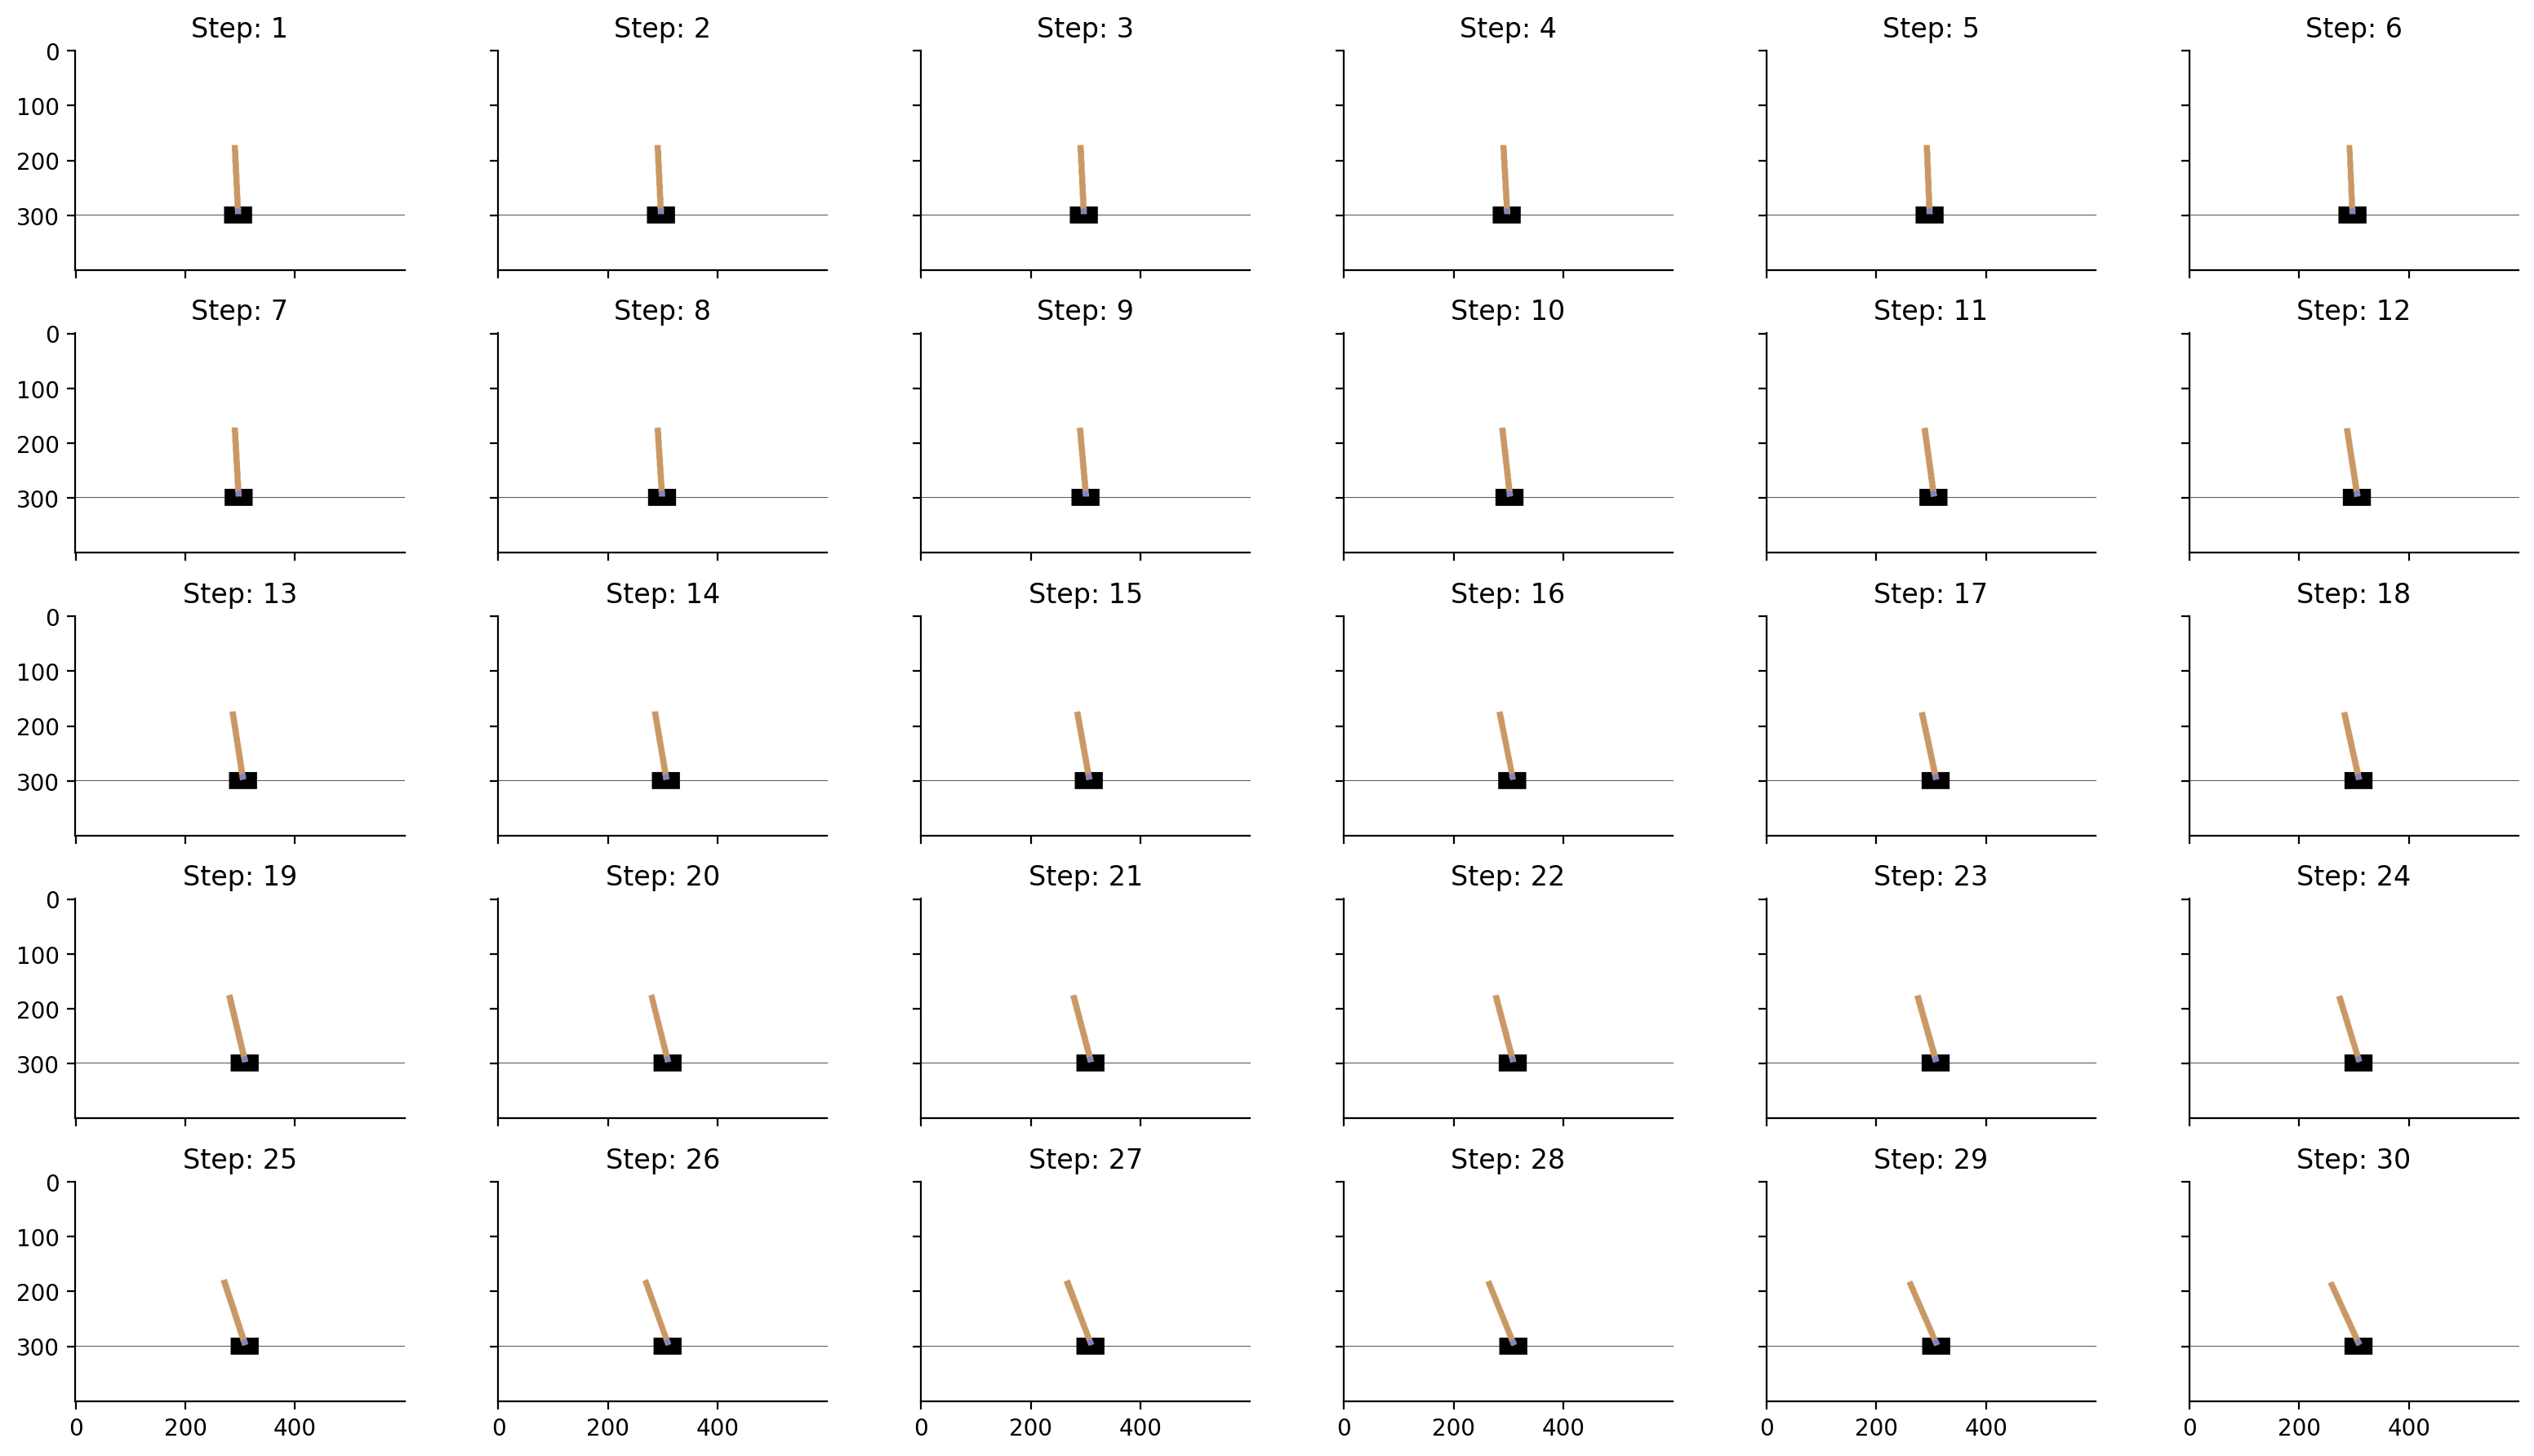

In [7]:
env = gym.make("CartPole-v1" , render_mode = "rgb_array")
state , info = env.reset()

fig , ax = plt.subplots(figsize = (16,9) , nrows=5 , ncols=6 , sharex=True , sharey = True)
ax_flat = ax.flatten()

 
for i in range(30):
    frame = env.render()
    action = env.action_space.sample()
    new_state , reward , terminated , truncated , info = env.step(action)
    state = new_state

    ax_flat[i].imshow(frame)
    ax_flat[i].set_title("Step: {}".format(i+1))
    ax_flat[i].set_frame_on(True)
    ax_flat[i].spines[['top', 'right']].set_visible(False)  

fig.tight_layout()
plt.show()
env.close()

Let us take a look at the possible actions.
You can find them here: https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py
As we can see, there are 4 observations:
* Cart Position (-4.8 to 4.8)
* Cart Velocity $(-\infty \text{ to } \infty)$
* Pole Angle (-0.418 to 0.418) rad or (-24 to 24) degrees
* Pole Angular Velocity $(-\infty \text{ to } \infty)$

and two actions:
* 0 - Move to the left
* 1 - Move to the right

The next cell contains code to play the game manually - Feel free to try it out by using the left and right arrow key

In [8]:
import pygame

In [9]:
# Initialize Pygame for keyboard input
pygame.init()
screen = pygame.display.set_mode((600, 400)) # Dummy window for event capture
clock = pygame.time.Clock()

env = gym.make("CartPole-v1" , render_mode = "human")
state , info = env.reset()

rewards = 0
action = 0 # Default action

for _ in range(500):
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            break
    keys = pygame.key.get_pressed()
    if keys[pygame.K_LEFT]:
        action = 0

    elif keys[pygame.K_RIGHT]:
        action = 1 
    else:
        action = 0 # Default to left/no-push if no key pressed

    # --- step environment ---
    state , reward , terminated , truncated , info = env.step(action)
    rewards += reward
    done = terminated or truncated

    if done:
        print(f"You got {rewards} points!")
        break

    clock.tick(50)

env.close()
pygame.quit()

You got 9.0 points!


# Part 2:
# Discretization for Q Table

We need to solve one problem before we can start working on the implementation:
The Q-Learning algorithm relies on the creation of discrete Q-Tables but our environment returns continuous values (angle and velocity).
So we need to discretize our observation, i.e we assign each observation to a discrete state.
To do so, we need to define a number of classes for each observation in order to assign each observation to one of those classes.<br />
In fact those classes are called *bins*

Let us just say that we want to allow 10 possible observations, thus each continuous observation is put into one of the 10 bins.
We can use *np.linspace(low, high, num)* for that. <br />
*np.linspace* creates a linearly spaced array from low to high containing num elements (10 in our case). <br />
The values used for low and high are the max value we took from the cartPole source code.(https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py). You can find them above. <br />
For the sake of convenience, we dont use the range $-\infty$ to $\infty$ for the velocity, but -5 to 5.


In [10]:
def create_bins(num_bins_per_action=10):
    bins_cart_position = np.linspace(-4.8, 4.8, num_bins_per_action)  # bins for the cart position
    bins_cart_velocity = np.linspace(-5, 5, num_bins_per_action)  # bins for the cart velocity
    bins_pole_angle = np.linspace(-0.418, 0.418, num_bins_per_action)  # bins for the pole angle
    bins_pole_angular_velocity = np.linspace(-5, 5, num_bins_per_action)  # bins for the pole angular velocity
    bins = np.array([bins_cart_position, bins_cart_velocity, bins_pole_angle, bins_pole_angular_velocity])  # merge them
    return bins

In [11]:
NUM_BINS = 10
BINS = create_bins(NUM_BINS)  # Create the bins used for the rest of the notebook
BINS

array([[-4.8       , -3.73333333, -2.66666667, -1.6       , -0.53333333,
         0.53333333,  1.6       ,  2.66666667,  3.73333333,  4.8       ],
       [-5.        , -3.88888889, -2.77777778, -1.66666667, -0.55555556,
         0.55555556,  1.66666667,  2.77777778,  3.88888889,  5.        ],
       [-0.418     , -0.32511111, -0.23222222, -0.13933333, -0.04644444,
         0.04644444,  0.13933333,  0.23222222,  0.32511111,  0.418     ],
       [-5.        , -3.88888889, -2.77777778, -1.66666667, -0.55555556,
         0.55555556,  1.66666667,  2.77777778,  3.88888889,  5.        ]])

In [12]:
BINS.shape , BINS.ndim

((4, 10), 2)

In [13]:
import seaborn as sns

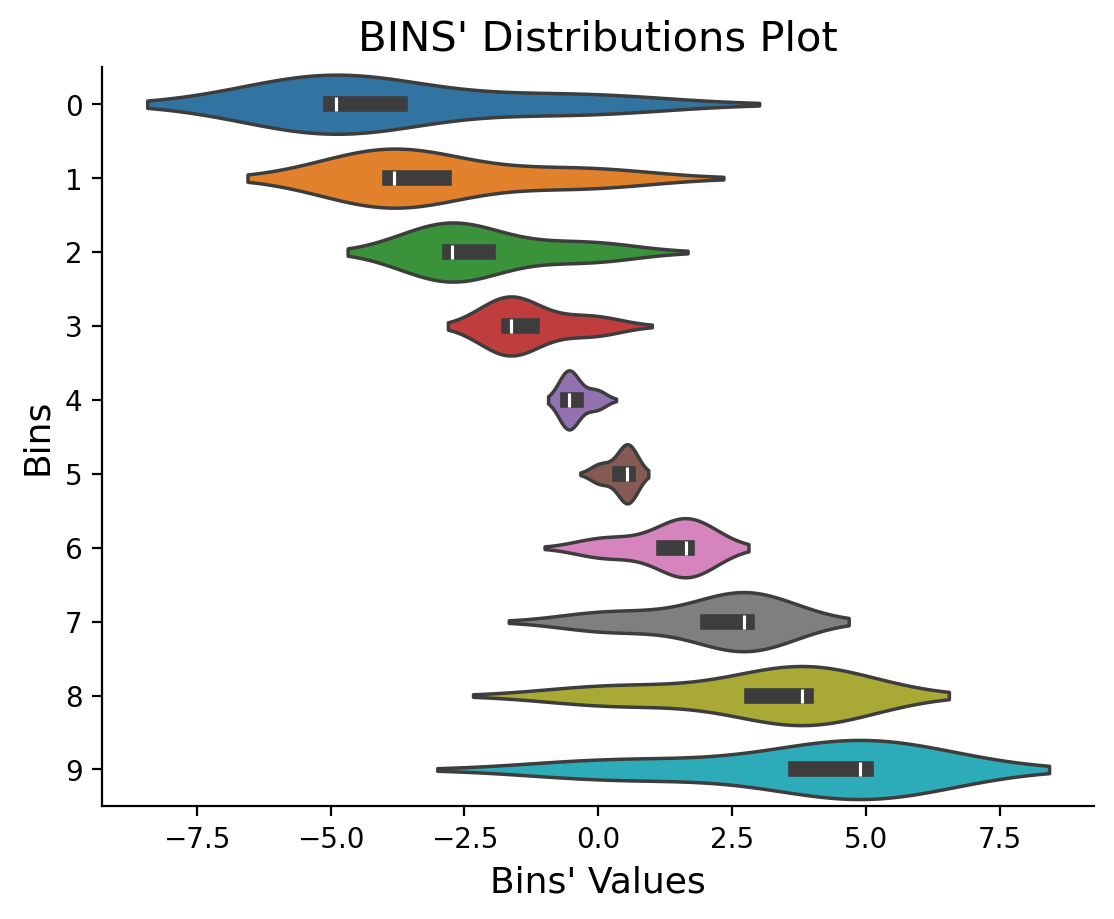

In [14]:
sns.violinplot(BINS, orient="h", dodge=False)
plt.title("BINS' Distributions Plot" , fontsize = 15)
plt.ylabel("Bins" , fontdict = {"size":13})
plt.xlabel("Bins' Values" , fontdict = {"size" : 13})
sns.despine()

We now defined our possible bins for each observation. Let's take a look at them:

In [15]:
print(f"Bins for Cart Position:\n {BINS[0]}", 
      f"Bins for Cart Velocity:\n {BINS[1]}", 
      f"Bins for Pole Angle:\n {BINS[2]}",
      f"Bins for Pole Angular Velocity :\n {BINS[3]}", 
      sep = "\n" + "-"*75 + "\n" )

Bins for Cart Position:
 [-4.8        -3.73333333 -2.66666667 -1.6        -0.53333333  0.53333333
  1.6         2.66666667  3.73333333  4.8       ]
---------------------------------------------------------------------------
Bins for Cart Velocity:
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]
---------------------------------------------------------------------------
Bins for Pole Angle:
 [-0.418      -0.32511111 -0.23222222 -0.13933333 -0.04644444  0.04644444
  0.13933333  0.23222222  0.32511111  0.418     ]
---------------------------------------------------------------------------
Bins for Pole Angular Velocity :
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]


## Mapping from Continuous to Discrete

------

We now need to write a function which maps each observation to one of those values.
Luckily numpy provides the function *digitize(data, bins)* for us which takes care of the mapping.
*np.digitize()* returns the index of the bin which is closest to the data to be mapped

In [16]:
### Digitize Demo ###
demo_bin = [0, 1, 2, 3, 4, 5]
demo_data = -10  # as 2 hast the closest distance to 2.4, the result
                 # of the digitize function should be 3, as 2 is located at the third index of the bins
print(np.digitize(demo_data, demo_bin))

0


In [38]:
def discretize_observation(observations, bins):
    observations = np.asanyarray(observations).flatten()
    binned_observations = []
    for i , observation in enumerate(observations):
        discretized_observation = np.digitize(observation, bins[i])
        binned_observations.append(discretized_observation)
    return tuple(binned_observations) # Important for later indexing

In [42]:
# Simulate one CartPole observation
test_obs = np.array([[0.012, 0.003, -0.04, 0.02]])   # shape (1, 4)

# One bin-edge array per dimension (lengths can differ)
test_bins = [
    np.linspace(-2.4, 2.4, 9),   # cart position
    np.linspace(-3.0, 3.0, 9),   # cart velocity
    np.linspace(-0.21, 0.21, 9), # pole angle
    np.linspace(-3.0, 3.0, 9),   # pole angular velocity
]

print(discretize_observation(test_obs, test_bins))
# -> e.g. (5, 5, 4, 5)  ← tuple of 4 ints

(np.int64(5), np.int64(5), np.int64(4), np.int64(5))


Let us test our function

In [43]:
env = gym.make("CartPole-v1", render_mode="human")
observation , info = env.reset()  # Remember that env.reset() returns the intial observation
print(f"Cart Position: {observation[0]}")
print(f"Cart Velocity: {observation[1]}")
print(f"Pole Angle: {observation[2]}")
print(f"Pole Angular Velocity : {observation[3]}")
env.close()

Cart Position: -0.03351810947060585
Cart Velocity: 0.027105366811156273
Pole Angle: 0.021268382668495178
Pole Angular Velocity : 0.03358028829097748


In [44]:
print(observation)

[-0.03351811  0.02710537  0.02126838  0.03358029]


In [45]:
for i in range(len(BINS)):
    print(BINS[i])

[-4.8        -3.73333333 -2.66666667 -1.6        -0.53333333  0.53333333
  1.6         2.66666667  3.73333333  4.8       ]
[-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]
[-0.418      -0.32511111 -0.23222222 -0.13933333 -0.04644444  0.04644444
  0.13933333  0.23222222  0.32511111  0.418     ]
[-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]


In [22]:
mapped_observation = discretize_observation(observation, BINS)
print(mapped_observation)

(np.int64(5), np.int64(5), np.int64(6), np.int64(5))


(5, 5, 6, 5) means that the three observations are assigned to bin 5 and the other is assigned to bin 6.
Lets check if that is correct

Bin 5 contains the values 0.53333/0.55555 for all observations which leads to bin 5 for each individual observation! <br />
But another test might be a good idea.
Lets define the array: <br />
test = (-5, 5, 0.2, -4). <br />
If our function works correctly, it should output:(0, 10, 7, 1) as those are the bins corresponding to those values

In [46]:
test = (-5 , 5 , 0.2 , -4)
discretize_observation(test, BINS)  # Nice!

(np.int64(0), np.int64(10), np.int64(7), np.int64(1))

Now that we validated the functionality of our function it is time to move on with the Q-Learning algorithm. <br />
Let us create the Q-Table:
Remember that the Q-Table has a cell for each permutation of state-action pair. <br />
As there are 4 possible observations, (with 10 bins each) and 2 actions this yields that:
$$10\times10\times10\times10\times2$$ cells are needed to cover all permutations

We can create the Q-Table by using np.zeros(shape)

In [59]:
q_table = np.zeros([len(e) + 1 for e in BINS] + [env.action_space.n])
print(q_table.shape)   # e.g. (11, 11, 11, 11, 2)

(11, 11, 11, 11, 2)


In [60]:
q_table

array([[[[[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         [[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         [[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         ...,

         [[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         [[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         [[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]]],


        [[[0., 0.],
          [0., 0.],
          [0., 0.],
          ...,
          [0., 0.],
          [0., 0.],
          [0., 0.]],

         [[0., 0.],
    

-------
--------
# Constants and Hyperparameters

In [49]:
EPOCHS = 20000
ALPHA = 0.8
GAMMA = 0.9

In [50]:
# Exploration vs. Exploitation parameters
epsilon = 1.0                 # Exploration rate
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability 
decay_rate = 0.001             # Exponential decay rate for exploration prob

## Now it is time to dive into the training / Q-Table update methodology.<br />
First we will define some functions needed for training phase

* epsilon_greedy_action_selection: Is used to implement the epsilon greedy action selection routine.
* fail: Defines the lowest amounts of points which actually count as **solved**, otherwise sets the reward to a very small value
* compute_next_q_value: Computes the next Q-Values according to the formula from the lecture
* reduce_epsilon: Reduces the $\epsilon$ used for the epsilon greedy algorithm

In [51]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    '''
    Returns an action for the agent. Note how it uses a random number to decide on
    exploration versus explotation trade-off.
    '''
    random_number = np.random.random()
    
    # EXPLOITATION, USE BEST Q(s,a) Value
    if random_number > epsilon:
        action = np.argmax(q_table[discrete_state])

    # EXPLORATION, USE A RANDOM ACTION
    else:
        # Return a random 0,1,2,3 action
        action = np.random.randint(0, env.action_space.n)
    return action

**FUNCTION FOR Q_VALUE COMPUTATION**

**Here we have our main Q-Learning update equation, note how it takes in the old q-value, the next optimal q value, along with our current reward, and then updates the next q value accordingly.**

In [52]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    q_val = old_q_value +  ALPHA * (reward + GAMMA * next_optimal_q_value - old_q_value)
    return q_val

**FUNCTION TO REDUCE EPSILON**

**As training continues, we need to balance explotation versus exploration, we want ot make sure our agent doesn't get trapped in a cycle going from an F square to another F Square back and forth. We also don't want our agent permanently choosing random values. We'll use the function below to try to balance this.**

*Note, this is an alternative to our previous exponential decay, its a linear decay. It's not worse or better, just an alternative.*

In [53]:
BURN_IN = 1
epsilon = 1

EPSILON_END= 10000
EPSILON_REDUCE = 0.0001

In [54]:
def reduce_epsilon(epsilon, epoch):
    if BURN_IN <= epoch <= EPSILON_END:
        epsilon-= EPSILON_REDUCE
    return epsilon

**CUSTOM REWARD VALUES**

In [55]:
def fail(done, points, reward):
    if done and points < 150:
        reward = -200
    return reward

## Training

<IPython.core.display.Javascript object>


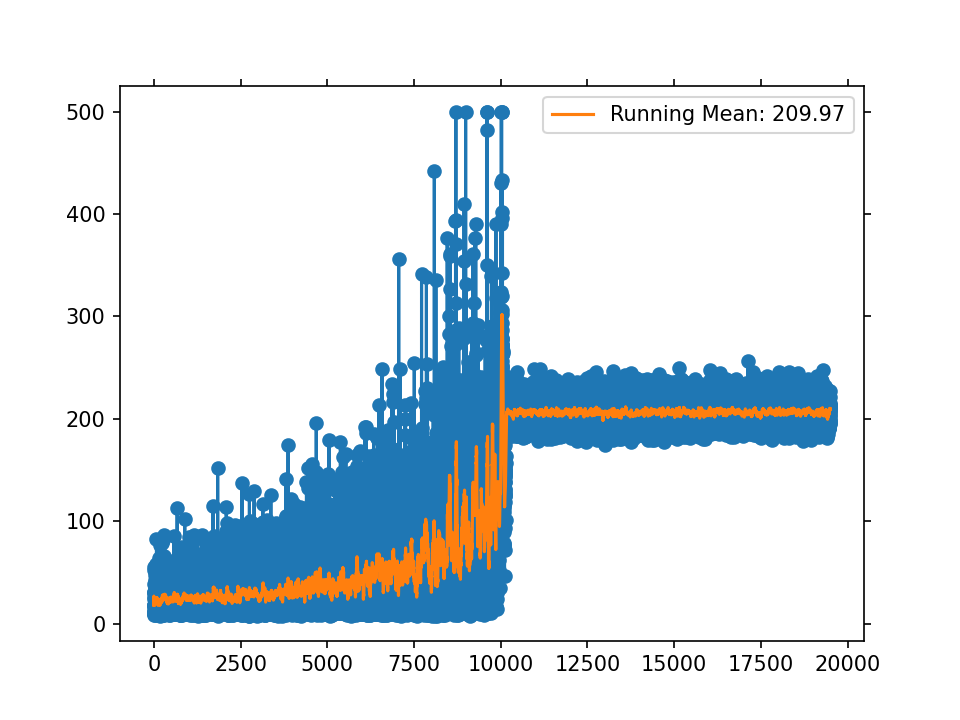

In [50]:
##############################################
### VISUALIZATION OF TRAINING PROGRESS ######
##############################################

log_interval = 500      # How often do we update the plot? (performance)
render_interval = 2000  # How often to render the game during training

### Live plotting setup ###
fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()
fig.canvas.draw()
##############################################

points_log = []       # all achieved points
mean_points_log = []  # running mean of last 30 results
epochs = []           # epoch numbers for plotting

env = gym.make("CartPole-v1", render_mode="rgb_array")

for epoch in range(EPOCHS):

    ## Continuous State --> Discrete State
    initial_state, info = env.reset()
    discretized_state = discretize_observation(initial_state, BINS)

    done = False
    points = 0

    epochs.append(epoch)

    while not done:

        # Optional: render occasionally
        # if epoch % render_interval == 0:
        #     env.render()

        # Epsilon-Greedy Action Selection
        action = epsilon_greedy_action_selection(epsilon, q_table, discretized_state)

        # Step the environment
        next_state, reward, terminated, truncated, info = env.step(action)

        # Combine terminated & truncated into a single done flag
        done = terminated or truncated

        # Adjust reward AFTER determining done
        reward = fail(done, points, reward)

        # Discretize the next state
        next_state_discretized = discretize_observation(next_state, BINS)

        # Get the old Q-Value from the Q-Table
        old_q_value = q_table[discretized_state + (action,)]

        # Get the next optimal Q-Value
        next_optimal_q_value = np.max(q_table[next_state_discretized])

        # Compute & store next Q-Value
        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)
        q_table[discretized_state + (action,)] = next_q

        # Update the state
        discretized_state = next_state_discretized
        points += 1

    # End of episode
    epsilon = reduce_epsilon(epsilon, epoch)
    points_log.append(points)

    running_mean = round(np.mean(points_log[-30:]), 2)
    mean_points_log.append(running_mean)

    ################ Plot the points and running mean ##################
    if epoch % log_interval == 0:
        ax.clear()
        ax.scatter(epochs, points_log, s=10)
        ax.plot(epochs, points_log, alpha=0.7)
        ax.plot(epochs, mean_points_log, label=f"Running Mean: {running_mean}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Points")
        ax.set_title("Training Progress")
        plt.legend()
        fig.canvas.draw()
        plt.pause(0.001)  # allow GUI to refresh
    ######################################################################

env.close()

Now it is time for a final evaluation round!
Let's see how well our first RL agent performs

# Final Agent Playing the Game

In [51]:
observation = env.reset()
rewards = 0
for _ in range(1000):
    env.render()
    discrete_state = discretize_observation(observation, BINS)  # get bins
    action = np.argmax(q_table[discrete_state])  # and chose action from the Q-Table
    observation, reward, terminated, truncated, info = env.step(action) # Finally perform the action
    rewards+=1
    if done:
        print(f"You got {rewards} points!")
        break
env.close()


You got 203 points!
